# Refined PBP With Server Coverage Check

This notebook pulls `prizepicksanalytics.originations_tennis.refined_pbp_with_server` and summarizes unique match coverage by `mode_best_of`.

In [30]:
import sys
from pathlib import Path

import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 400)

# Ensure local project imports resolve when running from notebooks/
project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from injestion.core.bq import get_client

In [2]:
bq_client = get_client()

table_id = "prizepicksanalytics.originations_tennis.refined_pbp_with_server"
query = f"SELECT * FROM `{table_id}`"

df = bq_client.query(query).to_dataframe()

print(f"Rows fetched: {len(df):,}")
print(f"Columns fetched: {len(df.columns)}")
df.head()

Rows fetched: 1,243,107
Columns fetched: 23


,sport_event_id,timeline_not_available,event_id,event_order,type,time,competitor,period_name,period,home_score,away_score,server,result,first_serve_fault,total_sets,mode_best_of,home_competitor_id,away_competitor_id,home_competitor_name,away_competitor_name,match_status,server_competitor_name,server_competitor_id
0,sr:sport_event:58211283,False,672764,10,point,2025-02-28 00:14:09+00:00,away,None,1.0,0,15,away,server_won,True,2,3,sr:competitor:891669,sr:competitor:300540,"Tien, Learner","Machac, Tomas",ended,"Machac, Tomas",sr:competitor:300540
1,sr:sport_event:58211283,False,672812,19,point,2025-02-28 00:19:31+00:00,away,None,1.0,15,40,home,receiver_won,<NA>,2,3,sr:competitor:891669,sr:competitor:300540,"Tien, Learner","Machac, Tomas",ended,"Tien, Learner",sr:competitor:891669
2,sr:sport_event:58211283,False,672887,30,period_score,2025-02-28 00:27:50+00:00,home,None,1.0,2,2,away,receiver_won,<NA>,2,3,sr:competitor:891669,sr:competitor:300540,"Tien, Learner","Machac, Tomas",ended,"Machac, Tomas",sr:competitor:300540
3,sr:sport_event:58211283,False,672902,33,point,2025-02-28 00:29:37+00:00,home,None,1.0,30,15,home,server_won,True,2,3,sr:competitor:891669,sr:competitor:300540,"Tien, Learner","Machac, Tomas",ended,"Tien, Learner",sr:competitor:891669
4,sr:sport_event:58211283,False,672906,34,point,2025-02-28 00:30:20+00:00,away,None,1.0,30,30,home,receiver_won,True,2,3,sr:competitor:891669,sr:competitor:300540,"Tien, Learner","Machac, Tomas",ended,"Tien, Learner",sr:competitor:891669


In [3]:
# Determine the match-level key column.
match_id_candidates = ["fixture_id", "sport_event_id", "game_id"]
match_id_col = next((c for c in match_id_candidates if c in df.columns), None)

if match_id_col is None:
    raise ValueError(
        "Could not identify match id column. Expected one of: "
        f"{match_id_candidates}. Found columns: {list(df.columns)}"
    )

if "mode_best_of" not in df.columns:
    raise ValueError("Column 'mode_best_of' is missing from the source table.")

print(f"Using match id column: {match_id_col}")

# Useful sanity checks
print("\nmode_best_of value counts (row-level):")
print(df["mode_best_of"].value_counts(dropna=False).sort_index())

# Match-level counts by mode_best_of
matches = (
    df[[match_id_col, "mode_best_of"]]
    .dropna(subset=[match_id_col])
    .drop_duplicates(subset=[match_id_col])
)

summary = (
    matches.groupby("mode_best_of", dropna=False)[match_id_col]
    .nunique()
    .reset_index(name="unique_matches")
    .sort_values("mode_best_of")
)

total_unique_matches = matches[match_id_col].nunique()
summary["pct_of_matches"] = (summary["unique_matches"] / total_unique_matches * 100).round(2)

print("\nUnique match counts by mode_best_of:")
display(summary)

print(f"Total unique matches: {total_unique_matches:,}")

# Focused best-of-3 vs best-of-5 view
bo3_bo5 = summary[summary["mode_best_of"].isin([3, 5])].copy()
print("\nBest-of-3 vs Best-of-5 unique matches:")
display(bo3_bo5)

bo3_count = int(bo3_bo5.loc[bo3_bo5["mode_best_of"] == 3, "unique_matches"].sum())
bo5_count = int(bo3_bo5.loc[bo3_bo5["mode_best_of"] == 5, "unique_matches"].sum())

if bo5_count > 0:
    print(f"Best-of-3 / Best-of-5 ratio: {bo3_count / bo5_count:.2f}x")
else:
    print("Best-of-3 / Best-of-5 ratio: undefined (no best-of-5 matches found)")

Using match id column: sport_event_id

mode_best_of value counts (row-level):
mode_best_of
3    1153146
5      89961
Name: count, dtype: Int64

Unique match counts by mode_best_of:


,mode_best_of,unique_matches,pct_of_matches
0,3,7921,95.33
1,5,388,4.67


Total unique matches: 8,309

Best-of-3 vs Best-of-5 unique matches:


,mode_best_of,unique_matches,pct_of_matches
0,3,7921,95.33
1,5,388,4.67


Best-of-3 / Best-of-5 ratio: 20.41x


In [6]:
df[df.sport_event_id == 'sr:sport_event:58211283'].head(10).sort_values(by='event_order', ascending=True)

,sport_event_id,timeline_not_available,event_id,event_order,type,time,competitor,period_name,period,home_score,away_score,server,result,first_serve_fault,total_sets,mode_best_of,home_competitor_id,away_competitor_id,home_competitor_name,away_competitor_name,match_status,server_competitor_name,server_competitor_id
0,sr:sport_event:58211283,False,672764,10,point,2025-02-28 00:14:09+00:00,away,None,1.0,0,15,away,server_won,True,2,3,sr:competitor:891669,sr:competitor:300540,"Tien, Learner","Machac, Tomas",ended,"Machac, Tomas",sr:competitor:300540
1,sr:sport_event:58211283,False,672812,19,point,2025-02-28 00:19:31+00:00,away,None,1.0,15,40,home,receiver_won,<NA>,2,3,sr:competitor:891669,sr:competitor:300540,"Tien, Learner","Machac, Tomas",ended,"Tien, Learner",sr:competitor:891669
2,sr:sport_event:58211283,False,672887,30,period_score,2025-02-28 00:27:50+00:00,home,None,1.0,2,2,away,receiver_won,<NA>,2,3,sr:competitor:891669,sr:competitor:300540,"Tien, Learner","Machac, Tomas",ended,"Machac, Tomas",sr:competitor:300540
3,sr:sport_event:58211283,False,672902,33,point,2025-02-28 00:29:37+00:00,home,None,1.0,30,15,home,server_won,True,2,3,sr:competitor:891669,sr:competitor:300540,"Tien, Learner","Machac, Tomas",ended,"Tien, Learner",sr:competitor:891669
4,sr:sport_event:58211283,False,672906,34,point,2025-02-28 00:30:20+00:00,away,None,1.0,30,30,home,receiver_won,True,2,3,sr:competitor:891669,sr:competitor:300540,"Tien, Learner","Machac, Tomas",ended,"Tien, Learner",sr:competitor:891669
5,sr:sport_event:58211283,False,672967,43,period_score,2025-02-28 00:37:30+00:00,home,None,1.0,3,3,away,receiver_won,True,2,3,sr:competitor:891669,sr:competitor:300540,"Tien, Learner","Machac, Tomas",ended,"Machac, Tomas",sr:competitor:300540
6,sr:sport_event:58211283,False,672983,45,point,2025-02-28 00:39:07+00:00,home,None,1.0,15,15,home,server_won,True,2,3,sr:competitor:891669,sr:competitor:300540,"Tien, Learner","Machac, Tomas",ended,"Tien, Learner",sr:competitor:891669
7,sr:sport_event:58211283,False,672993,48,point,2025-02-28 00:40:35+00:00,away,None,1.0,30,40,home,receiver_won,<NA>,2,3,sr:competitor:891669,sr:competitor:300540,"Tien, Learner","Machac, Tomas",ended,"Tien, Learner",sr:competitor:891669
8,sr:sport_event:58211283,False,672998,49,point,2025-02-28 00:41:06+00:00,home,None,1.0,40,40,home,ace,<NA>,2,3,sr:competitor:891669,sr:competitor:300540,"Tien, Learner","Machac, Tomas",ended,"Tien, Learner",sr:competitor:891669
9,sr:sport_event:58211283,False,673002,50,point,2025-02-28 00:41:42+00:00,away,None,1.0,40,50,home,receiver_won,True,2,3,sr:competitor:891669,sr:competitor:300540,"Tien, Learner","Machac, Tomas",ended,"Tien, Learner",sr:competitor:891669


## Data Quality Check 1: Duplicate Events

Audit and remove duplicate events before computing match-level targets.

In [16]:
# Duplicate-event audit and cleanup
# Primary dedupe key: (sport_event_id, event_id)
# This should uniquely identify a timeline event within a match.

required_cols = ["sport_event_id", "event_id"]
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns for duplicate check: {missing_required}")

rows_before = len(df)

# Focus duplicate check on rows where event_id is present.
df_with_event_id = df[df["event_id"].notna()].copy()
df_without_event_id = df[df["event_id"].isna()].copy()

dup_mask = df_with_event_id.duplicated(subset=["sport_event_id", "event_id"], keep="first")
duplicate_rows = df_with_event_id[dup_mask].copy()
rows_removed = int(dup_mask.sum())

print(f"Total rows before dedupe: {rows_before:,}")
print(f"Rows with non-null event_id: {len(df_with_event_id):,}")
print(f"Rows with null event_id (not deduped by event_id): {len(df_without_event_id):,}")
print(f"Duplicate rows removed (by sport_event_id + event_id): {rows_removed:,}")

if rows_removed > 0:
    affected_fixtures = duplicate_rows["sport_event_id"].nunique()
    print(f"Fixtures affected by duplicates: {affected_fixtures:,}")

    dup_summary = (
        df_with_event_id[df_with_event_id.duplicated(["sport_event_id", "event_id"], keep=False)]
        .groupby(["sport_event_id", "event_id"], as_index=False)
        .size()
        .rename(columns={"size": "duplicate_count"})
        .sort_values(["duplicate_count", "sport_event_id"], ascending=[False, True])
    )

    print("\nTop duplicate event groups:")
    display(dup_summary.head(5))

    print("\nSample duplicate rows for investigation:")
    sample_cols = [
        c for c in [
            "sport_event_id",
            "event_id",
            "event_order",
            "type",
            "time",
            "server",
            "result",
            "home_score",
            "away_score",
        ]
        if c in df.columns
    ]
    display(
        df_with_event_id[df_with_event_id.duplicated(["sport_event_id", "event_id"], keep=False)]
        .sort_values(["sport_event_id", "event_id", "event_order"]) 
        [sample_cols]
        .head(10)
    )
else:
    print("No duplicate events found on (sport_event_id, event_id).")

# Cleaned dataframe for downstream checks
# Keep all null-event_id rows, and dedupe rows with event_id.
df_clean = pd.concat([df_with_event_id[~dup_mask], df_without_event_id], ignore_index=True)

print(f"Total rows after dedupe: {len(df_clean):,}")
print(f"Row delta check (before - after): {rows_before - len(df_clean):,}")

Total rows before dedupe: 1,243,107
Rows with non-null event_id: 1,243,107
Rows with null event_id (not deduped by event_id): 0
Duplicate rows removed (by sport_event_id + event_id): 0
No duplicate events found on (sport_event_id, event_id).
Total rows after dedupe: 1,243,107
Row delta check (before - after): 0


## Build Fixture-Level Point Totals

Aggregate one row per `sport_event_id` and tally total points from rows where `type == "point"`.

In [60]:
# Fixture-level aggregation
# Uses deduped dataframe from prior step when available.

base_df = df_clean.copy() if "df_clean" in globals() else df.copy()

if "sport_event_id" not in base_df.columns:
    raise ValueError("Column 'sport_event_id' is required for fixture-level aggregation.")
if "type" not in base_df.columns:
    raise ValueError("Column 'type' is required to tally point rows.")

# Core point tally
# In this feed, game-clinching points can appear as `period_score`,
# so include both `point` and `period_score` in total point counts.
point_event_types = {"point", "period_score"}

# Game-end interpretation from period_score rows:
# - Holds: server_won OR ace
# - Breaks: receiver_won OR double_fault
point_totals = (
    base_df.assign(
        is_point_event=base_df["type"].isin(point_event_types).astype("int64"),
        is_raw_point=base_df["type"].eq("point").astype("int64"),
        is_period_score=base_df["type"].eq("period_score"),
        is_hold_event=(
            base_df["type"].eq("period_score")
            & base_df["result"].isin(["server_won", "ace"])
        ).astype("int64"),
        is_break_event=(
            base_df["type"].eq("period_score")
            & base_df["result"].isin(["receiver_won", "double_fault"])
        ).astype("int64"),
    )
    .groupby("sport_event_id", as_index=False)
    .agg(
        total_points=("is_point_event", "sum"),
        total_rows_in_pbp=("event_id", "size"),
        point_rows=("is_raw_point", "sum"),
        period_score_rows=("is_period_score", "sum"),
        total_serve_holds=("is_hold_event", "sum"),
        total_serve_breaks=("is_break_event", "sum"),
        first_event_time=("time", "min"),
        last_event_time=("time", "max"),
    )
)

# Fixture-level metadata (first non-null value observed within match)
metadata_cols = [
    "mode_best_of",
    "total_sets",
    "match_status",
    "home_competitor_id",
    "away_competitor_id",
    "home_competitor_name",
    "away_competitor_name",
]
metadata_cols = [c for c in metadata_cols if c in base_df.columns]

def first_non_null(series: pd.Series):
    non_null = series.dropna()
    return non_null.iloc[0] if len(non_null) else pd.NA

fixture_metadata = (
    base_df.groupby("sport_event_id", as_index=False)[metadata_cols]
    .agg(first_non_null)
    if metadata_cols
    else base_df[["sport_event_id"]].drop_duplicates()
)

fixture_point_totals = point_totals.merge(fixture_metadata, on="sport_event_id", how="left")

print("\nQuick summary of total_points:")
print(fixture_point_totals["total_points"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).round(2))

print("\nSample fixture-level output:")
display(
    fixture_point_totals.sort_values("total_points", ascending=False).head(5)
)

# Keep a canonical ordering for downstream checks
fixture_point_totals = fixture_point_totals.sort_values("sport_event_id").reset_index(drop=True)


Quick summary of total_points:
count    8309.00
mean      143.64
std        43.94
min        60.00
1%         79.00
5%         90.00
50%       133.00
95%       224.00
99%       279.00
max       395.00
Name: total_points, dtype: float64

Sample fixture-level output:


,sport_event_id,total_points,total_rows_in_pbp,point_rows,period_score_rows,total_serve_holds,total_serve_breaks,first_event_time,last_event_time,mode_best_of,total_sets,match_status,home_competitor_id,away_competitor_id,home_competitor_name,away_competitor_name
7113,sr:sport_event:67664536,395,403,334,61,53,8,2026-01-30 03:45:04+00:00,2026-01-30 09:14:57+00:00,5,5,ended,sr:competitor:407573,sr:competitor:57163,"Alcaraz, Carlos","Zverev, Alexander"
3467,sr:sport_event:61449519,387,396,326,61,55,6,2025-07-05 13:37:58+00:00,2025-07-05 18:46:49+00:00,5,5,ended,sr:competitor:294300,sr:competitor:104847,"Nakashima, Brandon","Sonego, Lorenzo"
2255,sr:sport_event:60690683,385,393,326,59,42,17,2025-06-08 13:27:47+00:00,2025-06-08 18:57:37+00:00,5,5,ended,sr:competitor:225050,sr:competitor:407573,"Sinner, Jannik","Alcaraz, Carlos"
3696,sr:sport_event:61512050,381,389,324,57,53,4,2025-07-01 11:36:08+00:00,2025-07-01 16:07:05+00:00,5,5,ended,sr:competitor:310974,sr:competitor:206879,"De Jong, Jesper","Eubanks, Christopher"
5254,sr:sport_event:63131185,378,386,317,61,51,10,2025-08-26 19:44:53+00:00,2025-08-27 00:34:09+00:00,5,5,ended,sr:competitor:127208,sr:competitor:601146,"Altmaier, Daniel","Medjedovic, Hamad"


## Merge Final Match Scores And Validate Minimum Points

Pull period-level set scores from `prizepicksanalytics.originations_tennis.sr_event_summaries`, compute fixture-level `total_games_played` and `total_tiebreaks_played`, merge into fixture totals, and validate `total_points >= 4 * total_games_played`.

In [61]:
import ast
import json

# Pull event summaries with period scores
summaries_table_id = "prizepicksanalytics.originations_tennis.sr_event_summaries"
summaries_query = f"""
SELECT
  sport_event_id,
  period_scores,
  competition_type,
  match_status,
  home_score,
  away_score,
  mode_best_of
FROM `{summaries_table_id}`
"""

event_summaries = bq_client.query(summaries_query).to_dataframe()
print(f"Event summary rows fetched: {len(event_summaries):,}")

required_summary_cols = ["sport_event_id", "period_scores"]
missing_summary_cols = [c for c in required_summary_cols if c not in event_summaries.columns]
if missing_summary_cols:
    raise ValueError(f"Missing expected columns in sr_event_summaries: {missing_summary_cols}")


def parse_period_scores(value):
    """Parse period_scores from list/dict/json-string into a python list[dict]."""
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return []
    if isinstance(value, list):
        return value
    if isinstance(value, tuple):
        return list(value)
    if isinstance(value, str):
        s = value.strip()
        if not s:
            return []
        # Try JSON first, then Python literal fallback.
        try:
            parsed = json.loads(s)
            return parsed if isinstance(parsed, list) else []
        except Exception:
            try:
                parsed = ast.literal_eval(s)
                return parsed if isinstance(parsed, list) else []
            except Exception:
                return []
    return []


def compute_total_games(period_scores_raw):
    """Sum games across set-level period scores."""
    period_scores = parse_period_scores(period_scores_raw)
    total_games = 0
    for entry in period_scores:
        if not isinstance(entry, dict):
            continue
        if entry.get("type") != "set":
            continue
        h = entry.get("home_score")
        a = entry.get("away_score")
        try:
            if pd.notna(h) and pd.notna(a):
                total_games += int(h) + int(a)
        except Exception:
            continue
    return total_games


def compute_total_tiebreaks(period_scores_raw):
    """Count set-level tiebreaks (7-6 or 6-7) from period scores."""
    period_scores = parse_period_scores(period_scores_raw)
    total_tiebreaks = 0
    for entry in period_scores:
        if not isinstance(entry, dict):
            continue
        if entry.get("type") != "set":
            continue
        h = entry.get("home_score")
        a = entry.get("away_score")
        try:
            if pd.notna(h) and pd.notna(a):
                h_int = int(h)
                a_int = int(a)
                if (h_int == 7 and a_int == 6) or (h_int == 6 and a_int == 7):
                    total_tiebreaks += 1
        except Exception:
            continue
    return total_tiebreaks


summary_games = event_summaries.copy()
summary_games["total_games_played"] = summary_games["period_scores"].apply(compute_total_games)
summary_games["total_tiebreaks_played"] = summary_games["period_scores"].apply(compute_total_tiebreaks)

# Keep one row per fixture id in case table has multiple rows per event.
summary_games_one_row = (
    summary_games.sort_values("sport_event_id")
    .drop_duplicates(subset=["sport_event_id"], keep="first")
    [[
        "sport_event_id",
        "total_games_played",
        "total_tiebreaks_played",
        "competition_type",
        "match_status",
        "home_score",
        "away_score",
        "mode_best_of",
    ]]
    .rename(columns={
        "competition_type": "summary_competition_type",
        "match_status": "summary_match_status",
        "home_score": "summary_home_sets",
        "away_score": "summary_away_sets",
        "mode_best_of": "summary_mode_best_of",
    })
)

# Merge into fixture-level point totals
fixture_point_totals = fixture_point_totals.merge(summary_games_one_row, on="sport_event_id", how="left")

print(f"Fixture rows after merge: {len(fixture_point_totals):,}")
print(
    "Fixtures missing total_games_played after merge: "
    f"{fixture_point_totals['total_games_played'].isna().sum():,}"
)
print(
    "Fixtures missing total_tiebreaks_played after merge: "
    f"{fixture_point_totals['total_tiebreaks_played'].isna().sum():,}"
)

# Restrict scope to singles only.
rows_before_singles_filter = len(fixture_point_totals)
fixture_point_totals = fixture_point_totals[
    fixture_point_totals["summary_competition_type"].astype("string").str.lower() == "singles"
].copy()
print(f"\nSingles-only fixtures kept: {len(fixture_point_totals):,}")
print(f"Rows removed by competition_type filter: {rows_before_singles_filter - len(fixture_point_totals):,}")

# Keep only fixtures where period_score coverage matches derived total games.
validation_df = fixture_point_totals[fixture_point_totals["total_games_played"].notna()].copy()
validation_df["period_score_matches_total_games"] = (
    validation_df["period_score_rows"].astype("int64") == validation_df["total_games_played"].astype("int64")
)

rows_before_period_score_filter = len(validation_df)
validation_df = validation_df[validation_df["period_score_matches_total_games"]].copy()
print(
    "Rows removed by period_score completeness filter: "
    f"{rows_before_period_score_filter - len(validation_df):,}"
)

# Normalize count features by games for stable rate features.
validation_df["break_rate"] = (
    validation_df["total_serve_breaks"] / validation_df["total_games_played"]
)

# Ace rate is added after refined_serve_stats merge if total_aces_match is available.
if "total_aces_match" in validation_df.columns:
    validation_df["ace_rate"] = (
        validation_df["total_aces_match"] / validation_df["total_games_played"]
    )

# Minimum-point validation: total_points must be at least 4 x total_games_played
validation_df["min_possible_points"] = 4 * validation_df["total_games_played"]
validation_df["violates_min_points"] = validation_df["total_points"] < validation_df["min_possible_points"]

violations = validation_df[validation_df["violates_min_points"]].copy()

print("\nMinimum points validation:")
print(f"Fixtures evaluated: {len(validation_df):,}")
print(f"Violations found: {len(violations):,}")

if len(validation_df) > 0:
    violation_rate = len(violations) / len(validation_df) * 100
    print(f"Violation rate: {violation_rate:.2f}%")

if len(violations) > 0:
    cols_to_show = [
        c
        for c in [
            "sport_event_id",
            "total_points",
            "total_games_played",
            "min_possible_points",
            "mode_best_of",
            "summary_mode_best_of",
            "match_status",
            "summary_match_status",
            "summary_competition_type",
            "summary_home_sets",
            "summary_away_sets",
            "home_competitor_name",
            "away_competitor_name",
        ]
        if c in violations.columns
    ]
    print("\nFixtures violating minimum-point rule:")
    display(
        violations[cols_to_show]
        .sort_values(["min_possible_points", "total_points"], ascending=[False, True])
        .head(5)
    )
else:
    print("No fixtures violate total_points >= 4 * total_games_played.")

# Quick sanity distribution view for upcoming outlier exploration
print("\nSanity stats:")
print(
    validation_df[["total_points", "total_games_played", "total_tiebreaks_played", "min_possible_points"]]
    .describe()
    .round(2)
)

# Canonical fixture-level table (singles only) for downstream feature building / upload.
fixture_features = validation_df.copy()

Event summary rows fetched: 28,175
Fixture rows after merge: 8,309
Fixtures missing total_games_played after merge: 0
Fixtures missing total_tiebreaks_played after merge: 0

Singles-only fixtures kept: 6,246
Rows removed by competition_type filter: 2,063
Rows removed by period_score completeness filter: 7

Minimum points validation:
Fixtures evaluated: 6,239
Violations found: 0
Violation rate: 0.00%
No fixtures violate total_points >= 4 * total_games_played.

Sanity stats:
       total_points  total_games_played  total_tiebreaks_played  \
count       6239.00             6239.00                 6239.00   
mean         149.59               23.41                    0.37   
std           46.12                6.95                    0.59   
min           63.00               12.00                    0.00   
25%          114.00               18.00                    0.00   
50%          140.00               22.00                    0.00   
75%          179.00               28.00              

In [62]:
fixture_features.head()

,sport_event_id,total_points,total_rows_in_pbp,point_rows,period_score_rows,total_serve_holds,total_serve_breaks,first_event_time,last_event_time,mode_best_of,total_sets,match_status,home_competitor_id,away_competitor_id,home_competitor_name,away_competitor_name,total_games_played,total_tiebreaks_played,summary_competition_type,summary_match_status,summary_home_sets,summary_away_sets,summary_mode_best_of,period_score_matches_total_games,break_rate,min_possible_points,violates_min_points
0,sr:sport_event:58211283,139,145,118,21,12,9,2025-02-28 00:04:59+00:00,2025-02-28 01:47:32+00:00,3,2,ended,sr:competitor:891669,sr:competitor:300540,"Tien, Learner","Machac, Tomas",21,0,singles,ended,0,2,3,True,0.428571,84,False
1,sr:sport_event:58211287,163,171,136,27,19,8,2025-02-28 02:29:48+00:00,2025-02-28 04:45:46+00:00,3,3,ended,sr:competitor:117916,sr:competitor:42379,"Shapovalov, Denis","Giron, Marcos",27,0,singles,ended,2,1,3,True,0.296296,108,False
2,sr:sport_event:58211289,156,162,135,21,12,9,2025-02-28 00:06:02+00:00,2025-02-28 02:13:11+00:00,3,2,ended,sr:competitor:294300,sr:competitor:25838,"Nakashima, Brandon","Goffin, David",21,1,singles,ended,2,0,3,True,0.428571,84,False
3,sr:sport_event:58211291,162,169,135,27,21,6,2025-03-01 01:04:50+00:00,2025-03-01 03:13:21+00:00,3,3,ended,sr:competitor:300540,sr:competitor:294300,"Machac, Tomas","Nakashima, Brandon",27,0,singles,ended,2,1,3,True,0.222222,108,False
4,sr:sport_event:58211293,94,100,78,16,10,6,2025-02-28 05:02:55+00:00,2025-02-28 06:15:47+00:00,3,2,ended,sr:competitor:157456,sr:competitor:809324,"Davidovich Fokina, Alejandro","Pacheco Mendez, Rodrigo",16,0,singles,ended,2,0,3,True,0.375000,64,False


## Total Points vs Total Games

Scatter plots split by match format (`best of 3` and `best of 5`).

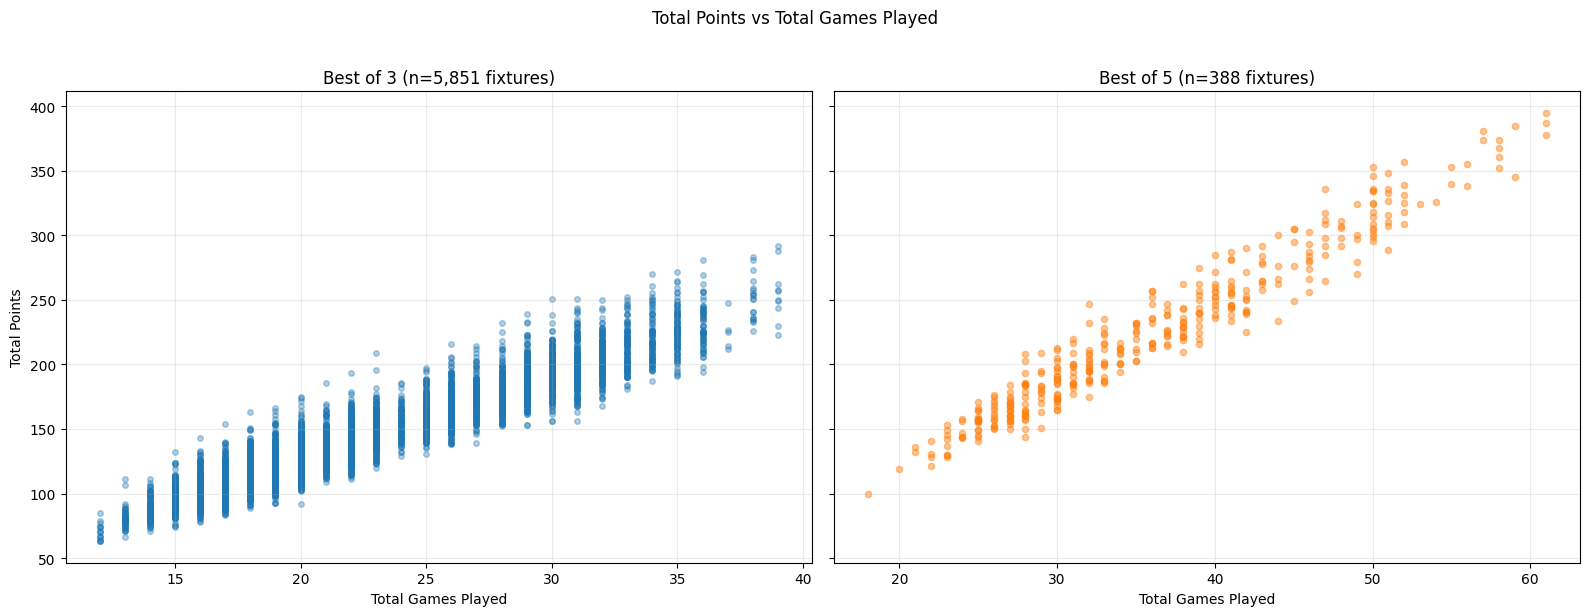

Counts used for plotting:
Best of 3 fixtures: 5,851
Best of 5 fixtures: 388


In [63]:
import matplotlib.pyplot as plt

# Use validated singles data when available.
plot_df = validation_df.copy() if "validation_df" in globals() else fixture_point_totals.copy()

required_plot_cols = ["total_points", "total_games_played"]
missing_plot_cols = [c for c in required_plot_cols if c not in plot_df.columns]
if missing_plot_cols:
    raise ValueError(f"Missing required plotting columns: {missing_plot_cols}")

# Prefer summary mode_best_of from event summaries; fallback to base mode_best_of.
if "summary_mode_best_of" in plot_df.columns:
    plot_df["best_of_for_plot"] = plot_df["summary_mode_best_of"]
elif "mode_best_of" in plot_df.columns:
    plot_df["best_of_for_plot"] = plot_df["mode_best_of"]
else:
    raise ValueError("Could not find best-of column for plotting.")

plot_df = plot_df.dropna(subset=["total_points", "total_games_played", "best_of_for_plot"]).copy()
plot_df["best_of_for_plot"] = pd.to_numeric(plot_df["best_of_for_plot"], errors="coerce")

bo3 = plot_df[plot_df["best_of_for_plot"] == 3]
bo5 = plot_df[plot_df["best_of_for_plot"] == 5]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Best-of-3
axes[0].scatter(
    bo3["total_games_played"],
    bo3["total_points"],
    alpha=0.35,
    s=16,
)
axes[0].set_title(f"Best of 3 (n={len(bo3):,} fixtures)")
axes[0].set_xlabel("Total Games Played")
axes[0].set_ylabel("Total Points")
axes[0].grid(alpha=0.25)

# Best-of-5
axes[1].scatter(
    bo5["total_games_played"],
    bo5["total_points"],
    alpha=0.45,
    s=20,
    color="tab:orange",
)
axes[1].set_title(f"Best of 5 (n={len(bo5):,} fixtures)")
axes[1].set_xlabel("Total Games Played")
axes[1].grid(alpha=0.25)

plt.suptitle("Total Points vs Total Games Played", y=1.02)
plt.tight_layout()
plt.show()

print("Counts used for plotting:")
print(f"Best of 3 fixtures: {len(bo3):,}")
print(f"Best of 5 fixtures: {len(bo5):,}")

## Data Quality Check 2: Period Score Completeness

Compare observed `period_score` event counts against expected total games from final set scores.

In [64]:
# Evaluate whether every completed game has a corresponding period_score event.

check_df = validation_df.copy() if "validation_df" in globals() else fixture_point_totals.copy()

required_cols = ["sport_event_id", "period_score_rows", "total_games_played"]
missing_cols = [c for c in required_cols if c not in check_df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns for period_score completeness check: {missing_cols}")

check_df = check_df.dropna(subset=["period_score_rows", "total_games_played"]).copy()
check_df["period_score_rows"] = pd.to_numeric(check_df["period_score_rows"], errors="coerce")
check_df["total_games_played"] = pd.to_numeric(check_df["total_games_played"], errors="coerce")
check_df = check_df.dropna(subset=["period_score_rows", "total_games_played"]).copy()

check_df["period_score_matches_total_games"] = (
    check_df["period_score_rows"].astype(int) == check_df["total_games_played"].astype(int)
)
check_df["period_score_game_delta"] = (
    check_df["period_score_rows"].astype(int) - check_df["total_games_played"].astype(int)
)

total_evaluated = len(check_df)
aligned_count = int(check_df["period_score_matches_total_games"].sum())
misaligned_count = total_evaluated - aligned_count
aligned_pct = (aligned_count / total_evaluated * 100) if total_evaluated else 0.0

print("Period-score completeness check:")
print(f"Fixtures evaluated: {total_evaluated:,}")
print(f"Aligned fixtures (period_score_rows == total_games_played): {aligned_count:,}")
print(f"Misaligned fixtures: {misaligned_count:,}")
print(f"Alignment rate: {aligned_pct:.2f}%")

if misaligned_count > 0:
    cols_to_show = [
        c
        for c in [
            "sport_event_id",
            "mode_best_of",
            "summary_mode_best_of",
            "period_score_rows",
            "total_games_played",
            "period_score_game_delta",
            "total_points",
            "summary_home_sets",
            "summary_away_sets",
            "home_competitor_name",
            "away_competitor_name",
            "summary_competition_type",
        ]
        if c in check_df.columns
    ]

    print("\nSample 5 misaligned fixtures:")
    display(
        check_df.loc[~check_df["period_score_matches_total_games"], cols_to_show]
        .sort_values(by="period_score_game_delta", key=lambda s: s.abs(), ascending=False)
        .head(5)
    )
else:
    print("\nNo misaligned fixtures found.")

Period-score completeness check:
Fixtures evaluated: 6,239
Aligned fixtures (period_score_rows == total_games_played): 6,239
Misaligned fixtures: 0
Alignment rate: 100.00%

No misaligned fixtures found.


## Merge Total Aces (Fixture-Level)

Pull player-level totals from `prizepicksanalytics.originations_tennis.refined_serve_stats`, sum `total_aces` across both players per fixture, and merge into the final fixture dataset.

In [65]:
# Pull player-level serve stats and aggregate to fixture-level total aces.
serve_stats_table_id = "prizepicksanalytics.originations_tennis.refined_serve_stats"
serve_stats_query = f"""
SELECT
  sport_event_id,
  competitor_id,
  total_aces
FROM `{serve_stats_table_id}`
"""

serve_stats_df = bq_client.query(serve_stats_query).to_dataframe()
print(f"Serve stats rows fetched: {len(serve_stats_df):,}")

required_ace_cols = ["sport_event_id", "total_aces"]
missing_ace_cols = [c for c in required_ace_cols if c not in serve_stats_df.columns]
if missing_ace_cols:
    raise ValueError(f"Missing expected columns in refined_serve_stats: {missing_ace_cols}")

# Ensure numeric total_aces before aggregation.
serve_stats_df["total_aces"] = pd.to_numeric(serve_stats_df["total_aces"], errors="coerce")

fixture_aces = (
    serve_stats_df.groupby("sport_event_id", as_index=False)
    .agg(
        total_aces_match=("total_aces", "sum"),
        serve_stats_rows=("sport_event_id", "size"),
        non_null_ace_rows=("total_aces", lambda s: int(s.notna().sum())),
    )
)

# Merge into canonical outputs (idempotent: drop prior ace columns first).
ace_cols = ["total_aces_match", "serve_stats_rows", "non_null_ace_rows"]

if "validation_df" in globals():
    validation_df = validation_df.drop(columns=[c for c in ace_cols if c in validation_df.columns], errors="ignore")
    validation_df = validation_df.merge(fixture_aces, on="sport_event_id", how="left")
    validation_df["ace_rate"] = validation_df["total_aces_match"] / validation_df["total_games_played"]

if "fixture_features" in globals():
    fixture_features = fixture_features.drop(columns=[c for c in ace_cols if c in fixture_features.columns], errors="ignore")
    fixture_features = fixture_features.merge(fixture_aces, on="sport_event_id", how="left")
    fixture_features["ace_rate"] = fixture_features["total_aces_match"] / fixture_features["total_games_played"]

print(f"Fixture rows in fixture_features: {len(fixture_features):,}")
print(
    "Fixtures missing total_aces_match: "
    f"{fixture_features['total_aces_match'].isna().sum():,}"
)

print("\nSample fixture-level aces columns:")
sample_cols = [
    c
    for c in [
        "sport_event_id",
        "total_aces_match",
        "serve_stats_rows",
        "non_null_ace_rows",
        "total_points",
        "total_games_played",
        "total_tiebreaks_played",
        "total_serve_holds",
        "total_serve_breaks",
    ]
    if c in fixture_features.columns
]
display(fixture_features[sample_cols].head(10))

Serve stats rows fetched: 16,618
Fixture rows in fixture_features: 6,239
Fixtures missing total_aces_match: 0

Sample fixture-level aces columns:


,sport_event_id,total_aces_match,serve_stats_rows,non_null_ace_rows,total_points,total_games_played,total_tiebreaks_played,total_serve_holds,total_serve_breaks
0,sr:sport_event:58211283,4.0,2,2,139,21,0,12,9
1,sr:sport_event:58211287,5.0,2,2,163,27,0,19,8
2,sr:sport_event:58211289,13.0,2,2,156,21,1,12,9
3,sr:sport_event:58211291,11.0,2,2,162,27,0,21,6
4,sr:sport_event:58211293,4.0,2,2,94,16,0,10,6
5,sr:sport_event:58211295,15.0,2,2,132,21,1,18,3
6,sr:sport_event:58211297,2.0,2,2,175,26,2,18,8
7,sr:sport_event:58211463,15.0,2,2,190,31,0,25,6
8,sr:sport_event:58211465,13.0,2,2,115,20,0,18,2
9,sr:sport_event:58211467,8.0,2,2,118,18,0,15,3


In [66]:
fixture_features.sample(5)

,sport_event_id,total_points,total_rows_in_pbp,point_rows,period_score_rows,total_serve_holds,total_serve_breaks,first_event_time,last_event_time,mode_best_of,total_sets,match_status,home_competitor_id,away_competitor_id,home_competitor_name,away_competitor_name,total_games_played,total_tiebreaks_played,summary_competition_type,summary_match_status,summary_home_sets,summary_away_sets,summary_mode_best_of,period_score_matches_total_games,break_rate,min_possible_points,violates_min_points,total_aces_match,serve_stats_rows,non_null_ace_rows,ace_rate
3541,sr:sport_event:62382116,140,146,117,23,22,1,2025-07-28 18:06:23+00:00,2025-07-28 19:42:55+00:00,3,2,ended,sr:competitor:405977,sr:competitor:863319,"Schoolkate, Tristan","Fonseca, Joao",23,1,singles,ended,2,0,3,True,0.043478,92,False,19.0,2,2,0.826087
2143,sr:sport_event:61077877,191,197,163,28,24,4,2025-06-09 11:06:35+00:00,2025-06-09 13:25:44+00:00,3,3,ended,sr:competitor:19836,sr:competitor:59702,"Kvitova, Petra","Haddad Maia, Beatriz",28,0,singles,ended,1,2,3,True,0.142857,112,False,2.0,2,2,0.071429
314,sr:sport_event:58903567,166,178,138,28,24,4,2025-03-25 16:11:59+00:00,2025-03-25 22:15:45+00:00,3,3,ended,sr:competitor:14844,sr:competitor:203681,"Monfils, Gael","Korda, Sebastian",28,0,singles,ended,1,2,3,True,0.142857,112,False,14.0,2,2,0.500000
1432,sr:sport_event:60373775,211,218,175,36,29,7,2025-05-06 14:52:47+00:00,2025-05-06 17:54:14+00:00,3,3,ended,sr:competitor:132834,sr:competitor:341220,"Barrios Vera, Marcelo Tomas","Royer, Valentin",36,0,singles,ended,2,1,3,True,0.194444,144,False,8.0,2,2,0.222222
926,sr:sport_event:59822566,288,294,249,39,25,14,2025-04-13 12:15:17+00:00,2025-04-13 15:49:15+00:00,3,3,ended,sr:competitor:92442,sr:competitor:124804,"Fett, Jana","Masarova, Rebeka",39,3,singles,ended,2,1,3,True,0.358974,156,False,9.0,2,2,0.230769
